In [5]:
from scripts.utils import check_data, preprocess_data, save_data
from scripts.utils import PROJECT_PATH, DATA_PATH, RESULTS_PATH, CELLTYPE_MAP, HISTOTYPE_MAP, ANNDATA_MAP, SUBSETS_CONFIG

from scripts.gene_subsampling import neyman_subsample
from scripts.studies import study_sparsity, study_sparsity_with_trajectories, study_complete_sparsity, study_group_sparsity, study_group_sparsity_exclude
import numpy as np

from scripts.clustering import cluster_data, find_best_resolution, find_best_resolution_linspace, best_leiden_run

from scripts.utils import plot_UMAP, update_data
import os

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import numpy as np
import scanpy as sc
import scvi


In [7]:
celltype="Fibroblasts"

fibroblast_cells = check_data(celltype=celltype,data_path=DATA_PATH)
if fibroblast_cells is None:
    fibroblast_cells = preprocess_data(celltype=celltype, with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=fibroblast_cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP[celltype]}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\mayeu\anaconda3\envs\env_scvi\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\mayeu\anaconda3\envs\env_scvi\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\mayeu\anaconda3\envs\env_scvi\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (4) is smaller than the logging

Epoch 123/400:  31%|███       | 123/400 [02:07<04:46,  1.03s/it, v_num=1, train_loss=3.61e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 3758.540. Signaling Trainer to stop.


C:\Users\mayeu\AppData\Local\Temp\ipykernel_9776\931763970.py:33: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


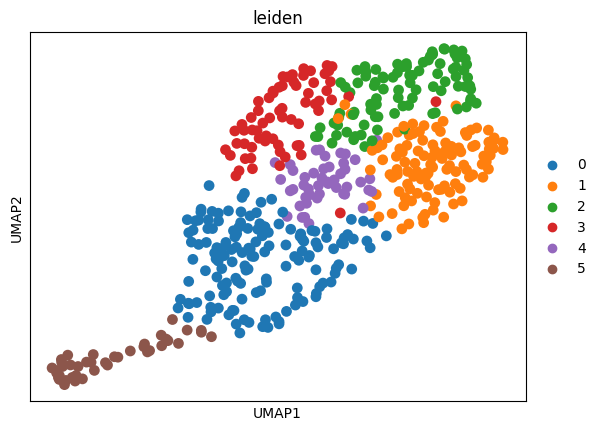

In [8]:
import numpy as np
from scipy.sparse import issparse

adata_total = fibroblast_cells.raw.to_adata()
adata = adata_total[:500].copy()

if issparse(adata.X):
    adata.X.data = np.round(adata.X.data).astype(int)

# ── 1. Préparer l'AnnData avec les counts bruts ──────────────────────────────

#sc.pp.filter_genes(adata, min_cells=10)

# ── 2. Setup et entraînement scVI ─────────────────────────────────────────────
adata.to_memory()

scvi.model.SCVI.setup_anndata(adata)

model = scvi.model.SCVI(
    adata,
    n_layers=2,
    n_latent=30,
    gene_likelihood="zinb",
)

model.train(max_epochs=400, early_stopping=True)

# ── 3. Extraire la représentation latente ─────────────────────────────────────
adata.obsm["X_scVI"] = model.get_latent_representation()

# ── 4. Clustering sur l'espace latent ─────────────────────────────────────────
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata, resolution=0.5)

# ── 5. UMAP pour visualisation ────────────────────────────────────────────────
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")

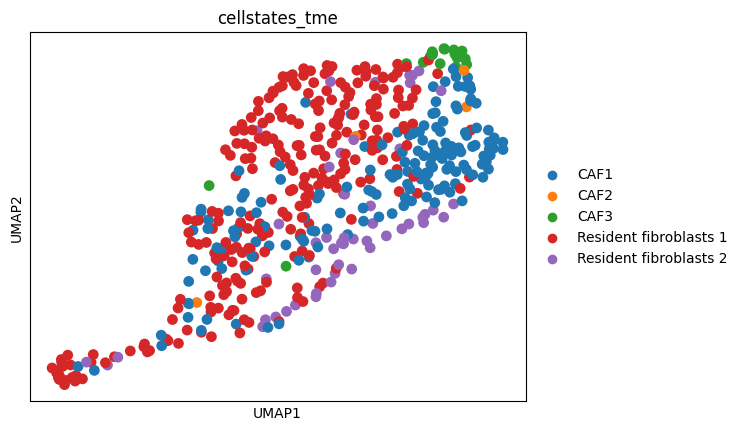

In [9]:
sc.pl.umap(adata, color="cellstates_tme")

In [15]:
adata.X.expm1()[:20,:20].data

array([1., 1., 1., 2., 2., 1., 6., 1., 2., 4., 1., 4., 2., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 4., 1., 2., 2., 2., 2., 1., 2., 2., 2., 1.,
       1., 2.])

In [ ]:
np.round(adata.X.expm1().data).

array([1, 1, 1, 1, 1, 1, 5, 1, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])